In [19]:
import pandas as pd

def get_da(tracking, grad_data, path):
    names = ["i", "lattice","optimization", "SGx1", "SGx2", "SGy1", "chrom_x", "chrom_y", "quad_kx", "quad_ky", "quad_kz", "obj", "eta1", "alpha0", "alpha1", "fr3", "gamma", "eb1", "particle"]
    df = pd.read_csv(grad_data, comment="#", sep='\\s+', header=0, names=names)
    files_for_tracking = []
    for i in range(len(df)):
        twiss_code = f"""
    INCLUDE '{df.at[i, 'lattice']}';
    
    PROCEDURE INJECT NUM; 
      VARIABLE X NUM; VARIABLE I 1;  VARIABLE K NUM;
    
       X := LINSPACE(-{tracking[0]}, {tracking[0]}, NUM);
    K := {tracking[1]};
    
      LOOP I 1 NUM;
        SR X|I 0 0 0 0 0 0 0 1;
        SR 0 0 X|I 0 0 0 0 0 1;
        SR X|I 0 0 0 0 K 0 0 1;
        SR 0 0 X|I 0 0 K 0 0 1;
      ENDLOOP;
    
    ENDPROCEDURE;
    
    PROCEDURE MAIN;
      VARIABLE WHERE 100;
      VARIABLE MRKR 50; VARIABLE DEG 10; VARIABLE SPIN_TUNE 10; VARIABLE CHROM 10; VARIABLE SEQ 10;
      VARIABLE GAMMA 1; VARIABLE MAPSE 1;
    VARIABLE MAPARR 1000 6 324; VARIABLE SPNRARR 1000 3 3 324;
      VARIABLE MU 800; VARIABLE NBAR 800 3; VARIABLE EL 1;
    
      VARIABLE PNUM 1;
      VARIABLE PSI0_DEG 1;
      VARIABLE NTURN 1;
      VARIABLE SGx1 1; VARIABLE SGy1 1;
      VARIABLE SGx2 1; VARIABLE SGy2 1;
      VARIABLE EB1 1; VARIABLE EB2 1;
    
      OV 4 3 0;
    GAMMA:={df.at[i, 'gamma']};
    SET_FOR_{df.at[i, 'particle']} GAMMA;
    EB1 := {df.at[i, 'eb1']};
    
      PNUM :={tracking[2]};
      NTURN := 10000;
    
      SGx1 :=  {df.at[i, 'SGx1']};
      SGy1  := {df.at[i, 'SGy1']};
      SGx2 :=  {df.at[i, 'SGx2']};
      SGy2  := 0;
    
    LATTICE SGx1 SGy1 SGx2 SGy2 GAMMA 1; PM 6;
      INJECT PNUM;
    
    MRKR := '{df.at[i, 'lattice']}_{df.at[i, 'optimization']}2';
    
    OPENF 772 '{path}/'&MRKR&'.dat' 'REPLACE';
    TRPRAY 772;
    
     TR NTURN 10 1 2 20 20 0 0 -1;
      CLOSEF 772;
    
    ENDPROCEDURE; 
    
    PROCEDURE RUN;
      MAIN;
    ENDPROCEDURE;
    RUN; END;
            
                """
        with open(f"{path}/{df.at[i, 'lattice']}_{df.at[i, 'optimization']}2.fox", "w") as f:
            f.write(twiss_code)
        name = f"{df.at[i, 'lattice']}_{df.at[i, 'optimization']}2"
        files_for_tracking.append((i, name, df.at[i, 'lattice'], df.at[i, 'optimization']))
    return (files_for_tracking)

grad_data = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/dynamic aperture/cosy/grad_data.dat"
path = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/dynamic aperture/cosy"
tracking_vars = [0.03, 1e-4, 150, 10000]

files = get_da(tracking_vars, grad_data, path)

def table(ff):
    path = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/dynamic aperture/cosy"
    rus = {
        "seq_FSp": "FSp",
        "seq_qfs": "QFS",
        "seq_dfs_pp1": "FSd",
        "chrom_correction": "бетатронная_хроматичность",
        "spin_coherence": "спиновая_когерентность",
        "seq_FSp_fr3": "FSp",
        "seq_qfs_fr3": "QFS",
        "seq_dfs_pp1_fr3": "FSd"
    }
    fringe_items = {"seq_FSp_fr3", "seq_qfs_fr3", "seq_dfs_pp1_fr3"}
    d = "natural_chrom"

    # Сортировка по ff[1], ff[2]
    ff_sorted = sorted(ff, key=lambda x: (x[2], x[3]))

    with open(f"{path}/table_template.dat", "w", encoding="utf-8") as f:
        f.write(f"#{'lattice':10} {'mode':25} {'fringe':25} {'plane':15} {'a':15} {'b':15}\n")
        
        for row in ff_sorted:
            lattice = rus.get(row[2], row[2])
            mode = rus.get(row[3], row[3])
            fringe = "краевые_поля" if row[2] in fringe_items else " - "
            
            if row[3] != d:
                for plane in ["X", "Y"]:
                    f.write(f"{lattice:10} {mode:25} {fringe:25} {plane:15} {'':15} {'':15}\n")
table(files)


a = "seq_FSp"
b = "seq_qfs"
c = "seq_dfs_pp1"
d = "natural_chrom"
print("Трекать файлы:")
for i in range(len(files)):
    if (files[i][3] != d):
        print(i, files[i][1])

Трекать файлы:
3 seq_qfs_fr3_spin_coherence2
4 seq_dfs_pp1_fr3_spin_coherence2
5 seq_FSp_spin_coherence2
6 seq_dfs_pp1_spin_coherence2
7 seq_qfs_spin_coherence2
11 seq_FSp_chrom_correction2
12 seq_dfs_pp1_chrom_correction2
13 seq_qfs_chrom_correction2
14 seq_FSp_fr3_spin_coherence2
15 seq_FSp_fr3_chrom_correction2
16 seq_dfs_pp1_fr3_chrom_correction2
17 seq_qfs_fr3_chrom_correction2


In [31]:
import subprocess
import os

fileid = 17
c = f"{files[fileid][1]}.fox"
subprocess.Popen(f'start cmd /c "cd /d {path} && cosy {c}"', shell=True)

<Popen: returncode: None args: 'start cmd /c "cd /d C:/Users/palo4/Desktop/M...>

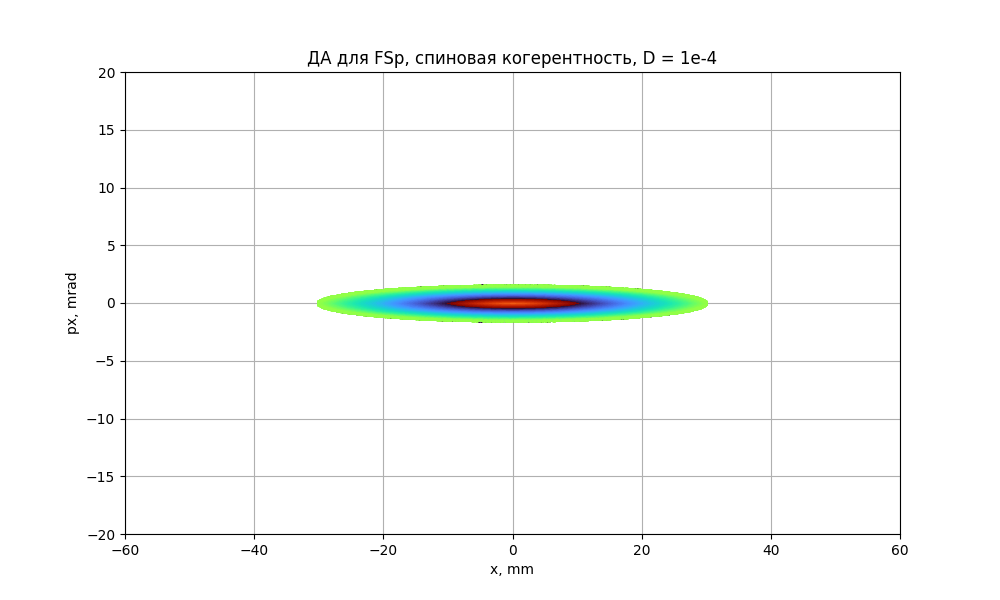

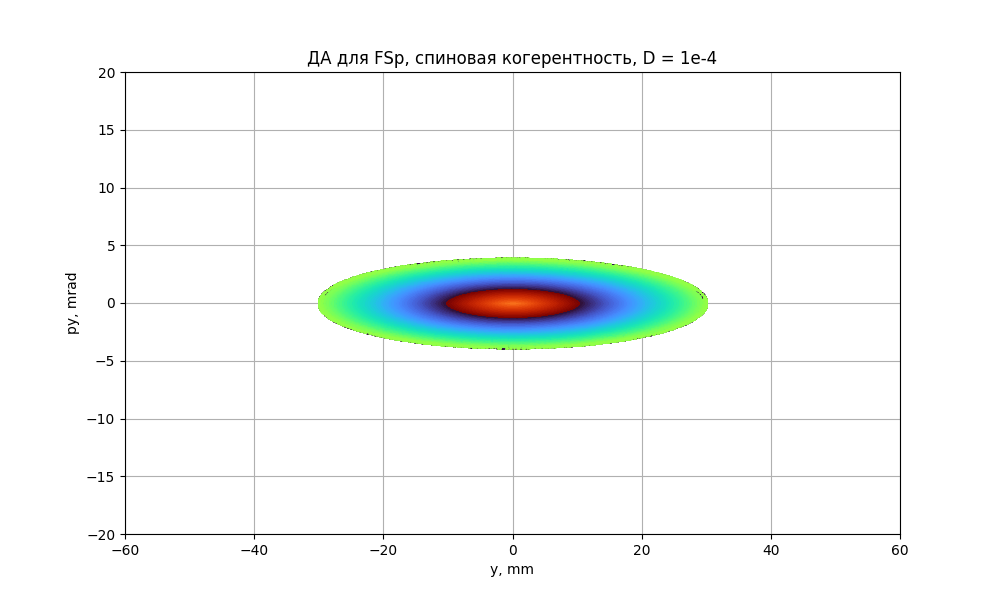

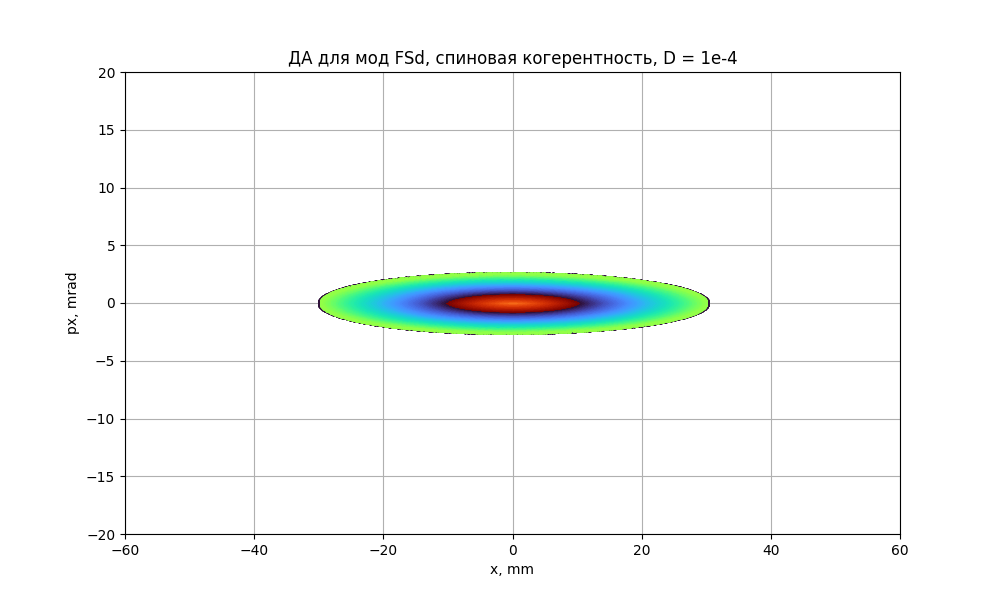

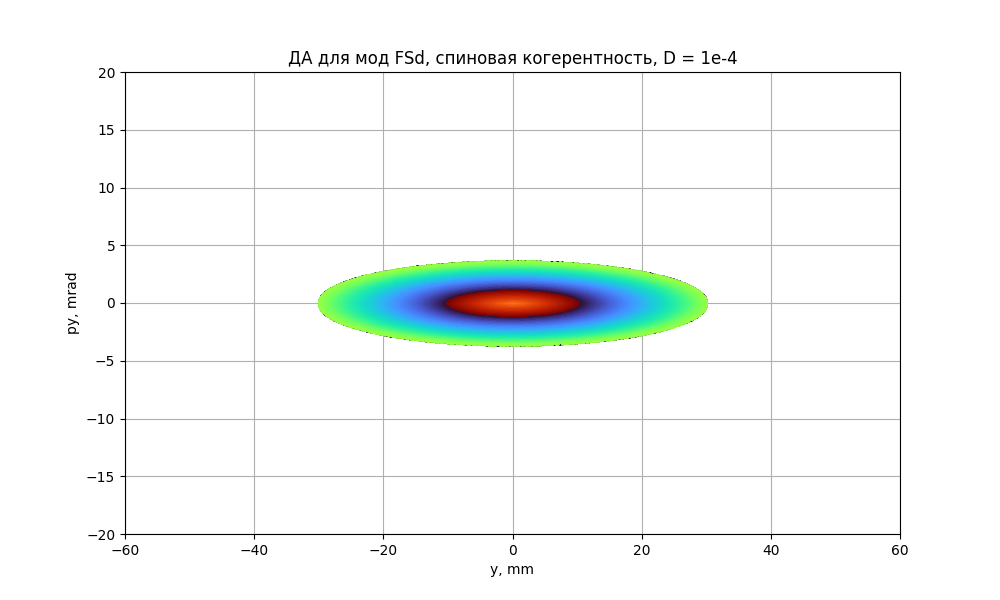

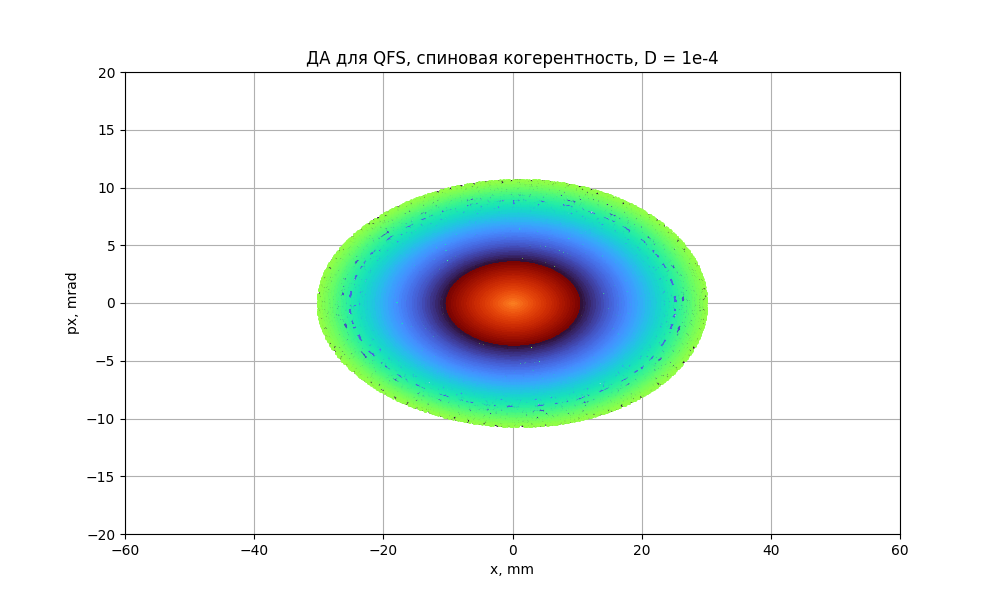

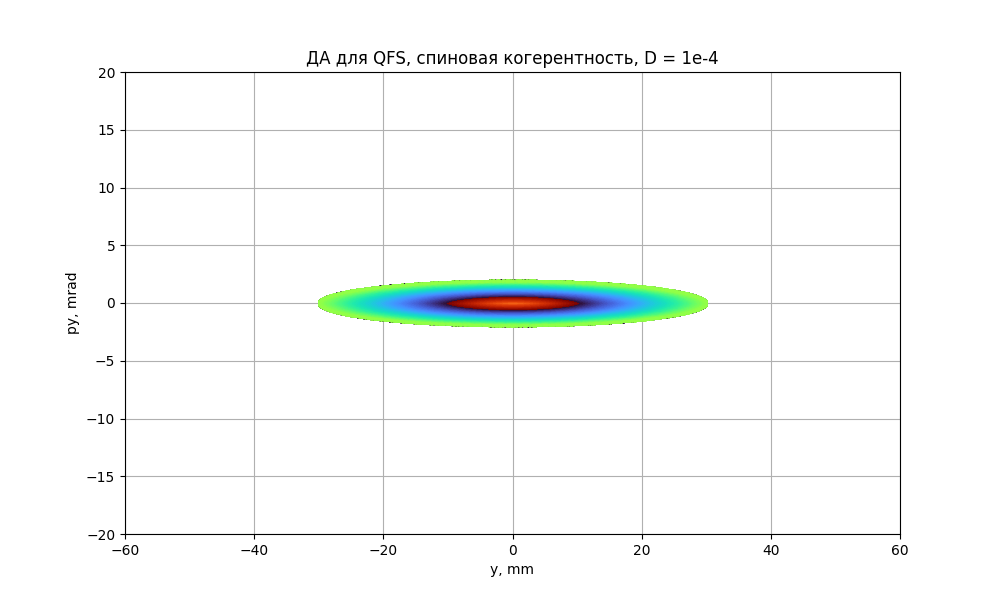

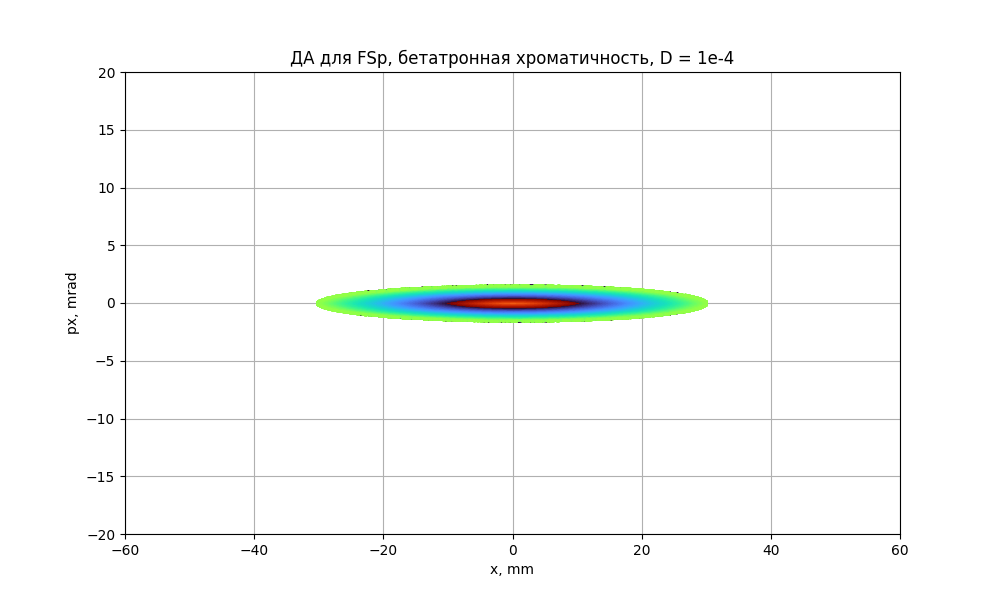

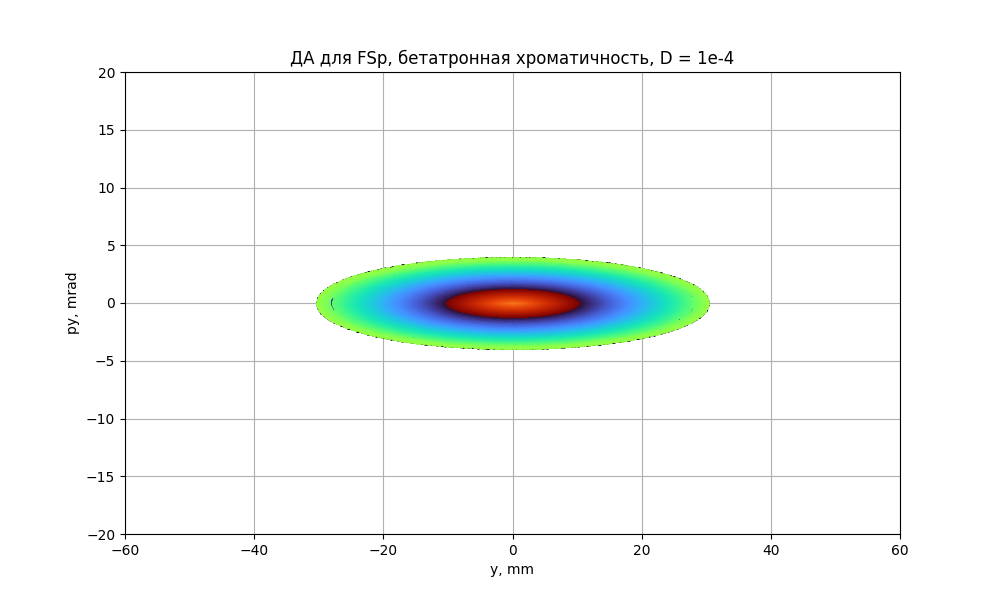

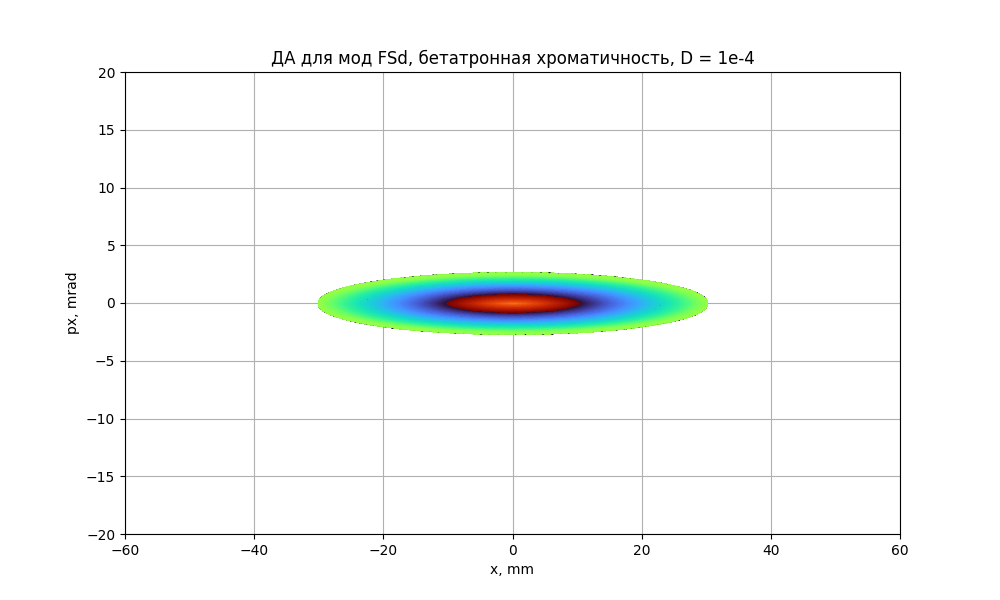

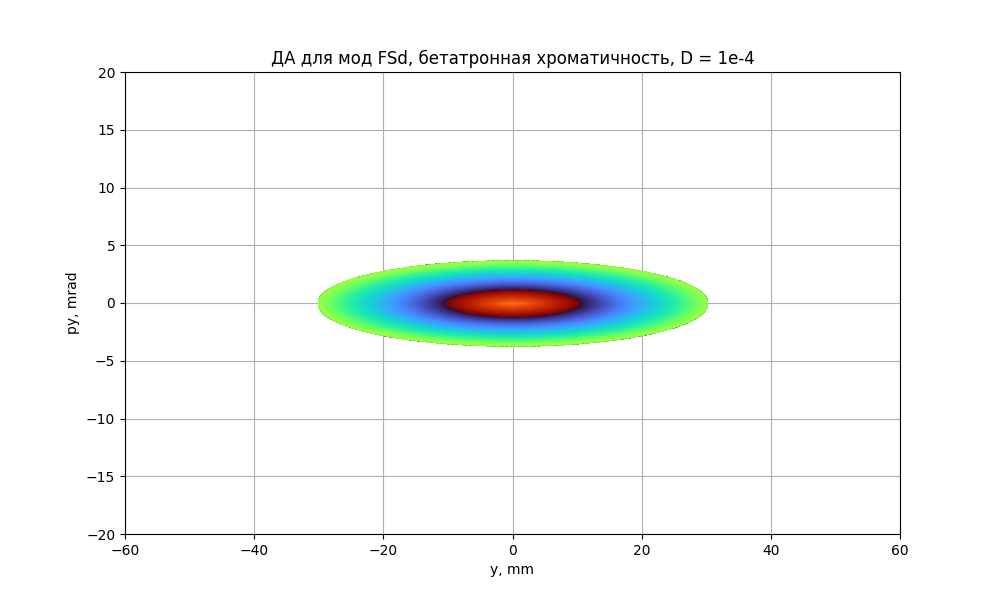

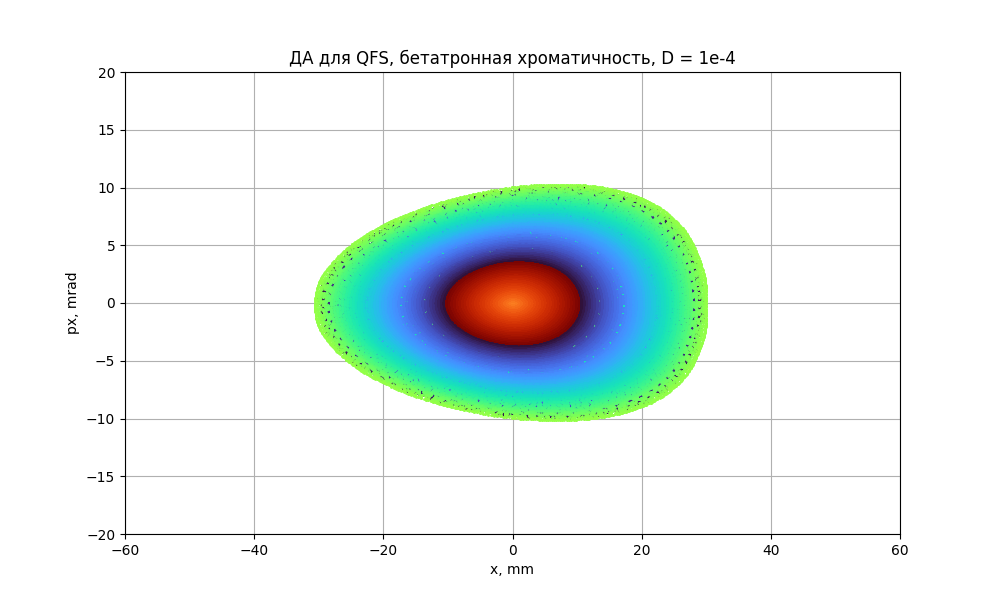

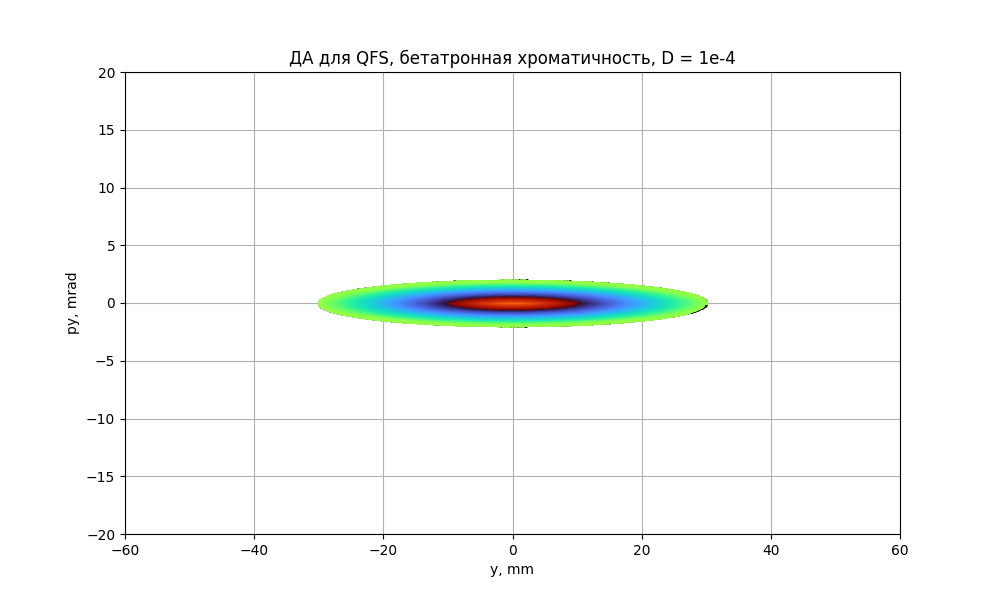

'       \n        plt.figure(figsize=(10,6))\n        for j in range(1, 4*(tracking_vars[2]) + 1, 4):\n            # X-plane, D = 0\n            rayx = df[df[\'ray\'] == j]\n            plt.plot(\n                rayx[\'x\'], rayx[\'a\'],\n                color=colors[((j - 1)//4) % len(colors)],\n                marker=\'o\',\n                linestyle=\'None\',\n                markersize=1,\n            )\n        plt.xlabel(\'x, m\')\n        plt.xlim(-45e-2, 45e-2)\n        plt.ylim(-30e-3, 30e-3)\n        plt.ylabel(\'px\')\n        plt.title(f"DA for {rus[files[i][2]]}, mode = {rus[files[i][3]]}, D = 0")\n        plt.grid(True)\n        plt.show()\n\n            # Y-plane, D = 0\n        plt.figure(figsize=(10,6))\n        for j in range(1, 4*(tracking_vars[2]) + 1, 4):\n            rayy = df[df[\'ray\'] == j+1]\n            plt.plot(\n                rayy[\'y\'], rayy[\'b\'],\n                color=colors[((j - 1)//4) % len(colors)],\n                marker=\'o\',\n            

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mplcursors

rus = {
    "seq_FSp": "FSp",
    "seq_qfs": "QFS",
    "seq_dfs_pp1": "мод FSd",
    "seq_dfs_pp1": "мод FSd",
    "chrom_correction": "бетатронная хроматичность",
    "spin_coherence": "спиновая когерентность"
}
a = "seq_FSp_fr3"
b = "seq_qfs_fr3"
c = "seq_dfs_pp1_fr3"

for i in range(len(files)):
    if (files[i][3] != "natural_chrom") and (files[i][2] not in [a, b, c]):
        filename = f"{path}/{files[i][1]}.dat"
        names = ["iteration", "ray", "x", "a", "y", "b", "T", "D"]
        
        # Чтение и сортировка данных
        df = pd.read_csv(filename, comment="#", sep=r'\s+', names=names)
        df = df.sort_values(by=["iteration", "ray"])  # сначала по iteration, потом по ray
        
        colors = plt.cm.turbo(np.linspace(0, 1, 100 + 1))
        plt.figure(figsize=(10,6))

        for j in range(1, 4*(tracking_vars[2]) + 1, 4):
            rayxd = df[df['ray'] == j+2]
            plt.plot(
                rayxd['x']*1e3, rayxd['a']*1e3,
                color=colors[((j - 1)//4) % len(colors)],
                marker='o',
                linestyle='None',
                markersize=1,
            )
        plt.xlabel('x, mm')
        plt.xlim(-6e-2*1e3, 6e-2*1e3)
        plt.ylim(-0.02*1e3, 0.02*1e3)
        plt.ylabel('px, mrad')
        plt.title(f"ДА для {rus[files[i][2]]}, {rus[files[i][3]]}, D = 1e-4")
        plt.grid(True)
        plt.show()
        
        plt.figure(figsize=(10,6))
        for j in range(1, 4*(tracking_vars[2]) + 1, 4):
            rayyd = df[df['ray'] == j+3]
            plt.plot(
                rayyd['y']*1e3, rayyd['b']*1e3,
                color=colors[((j - 1)//4) % len(colors)],
                marker='o',
                linestyle='None',
                markersize=1,
            )
        plt.xlabel('y, mm')
        plt.xlim(-6e-2*1e3, 6e-2*1e3)
        plt.ylim(-0.02*1e3, 0.02*1e3)
        plt.ylabel('py, mrad')
        plt.title(f"ДА для {rus[files[i][2]]}, {rus[files[i][3]]}, D = 1e-4")
        plt.grid(True)
        plt.show()


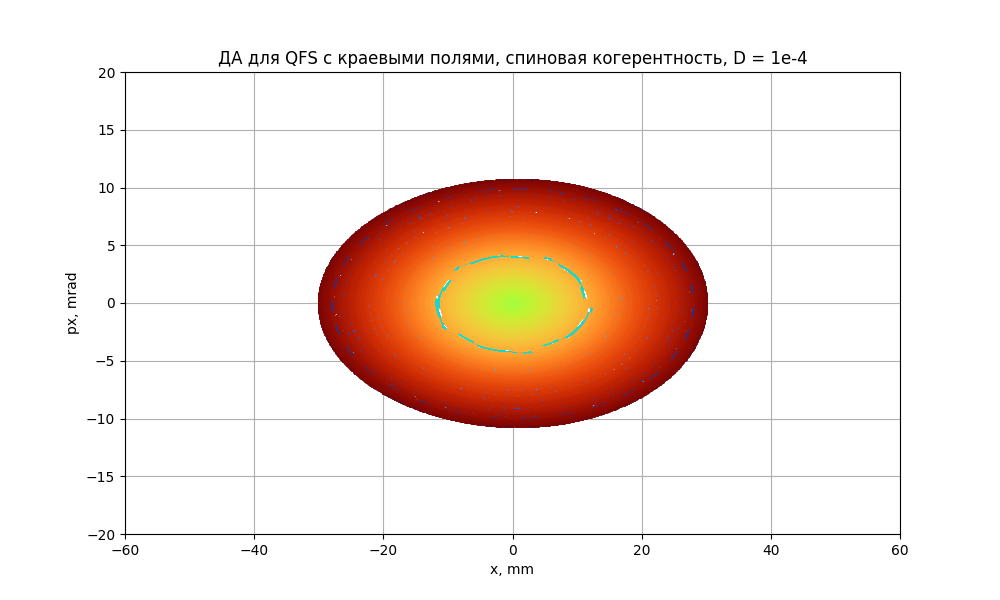

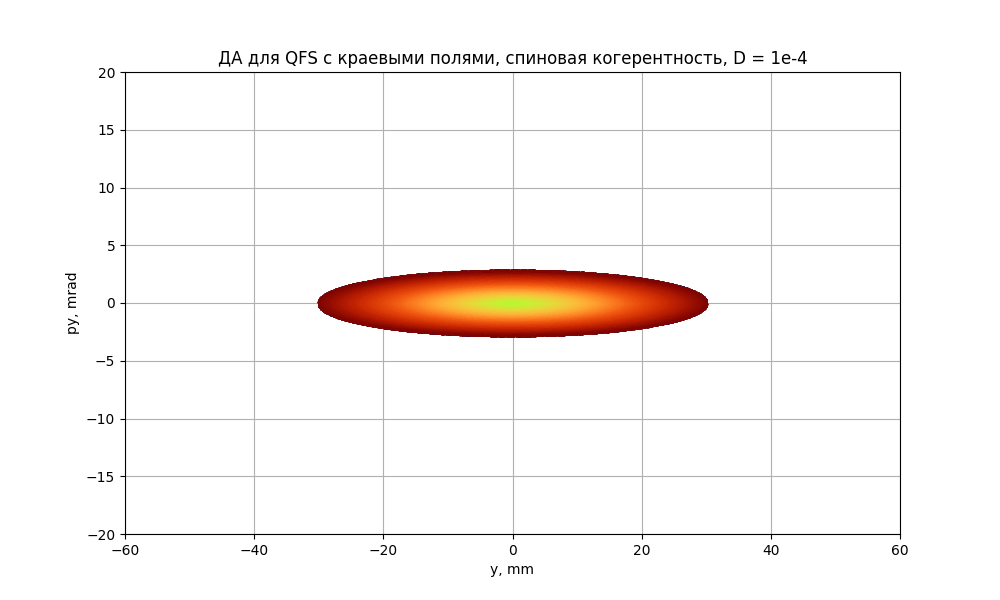

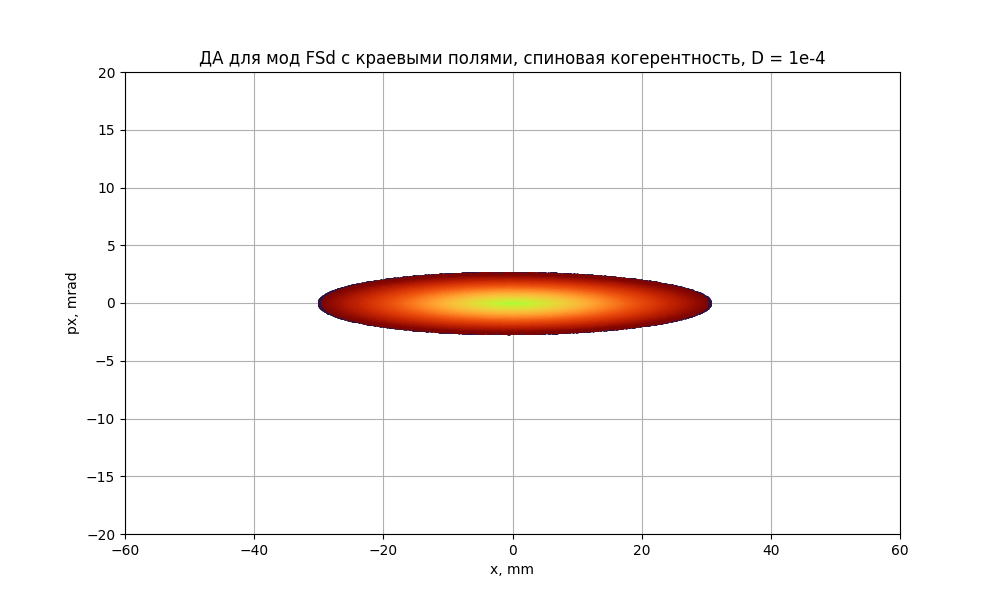

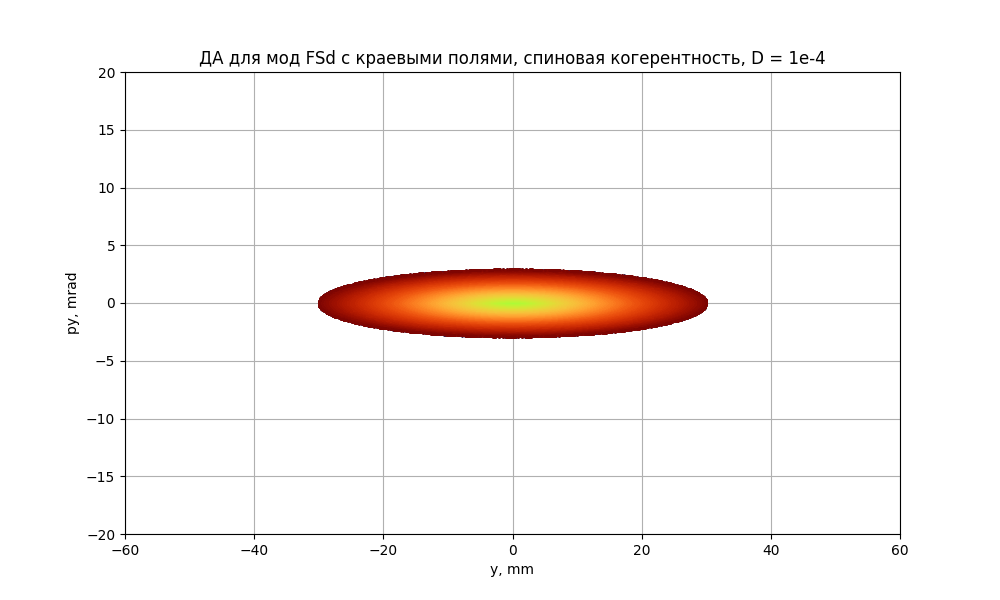

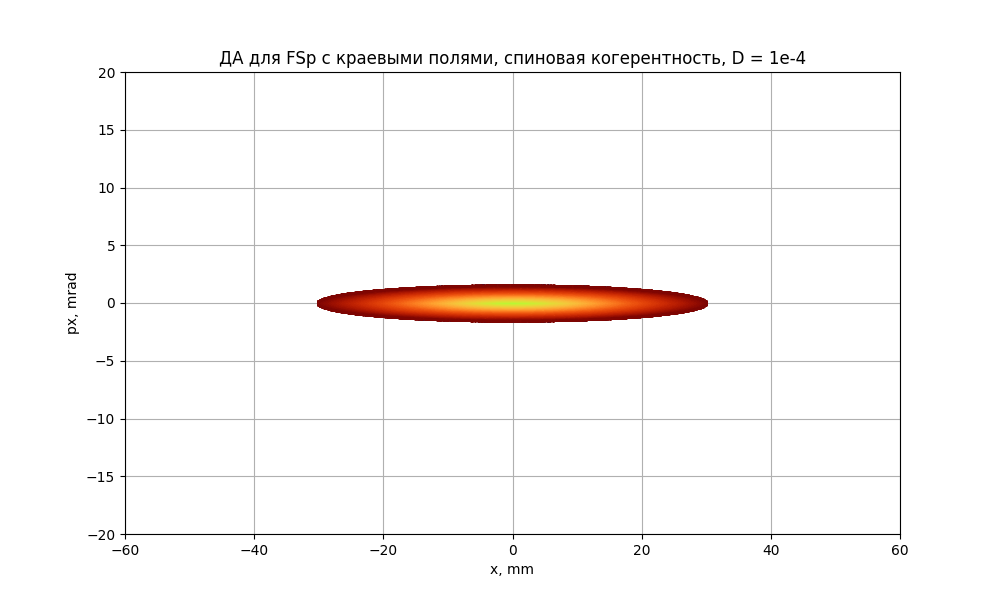

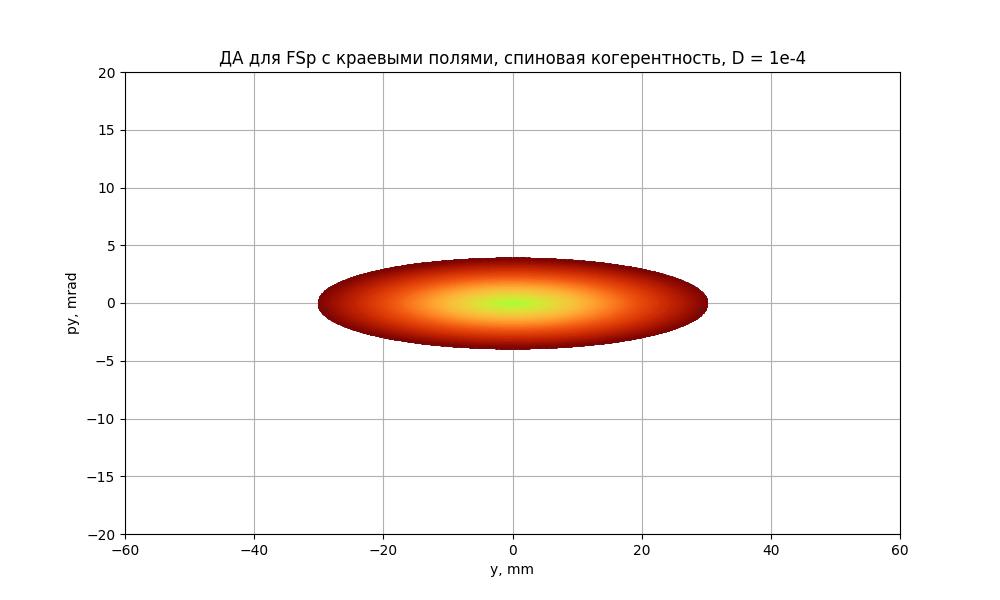

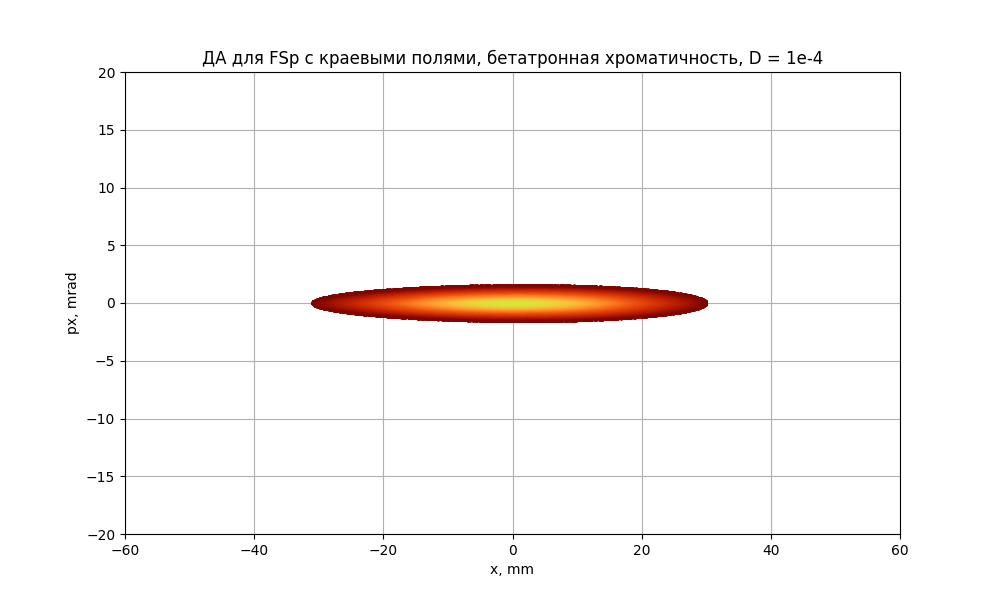

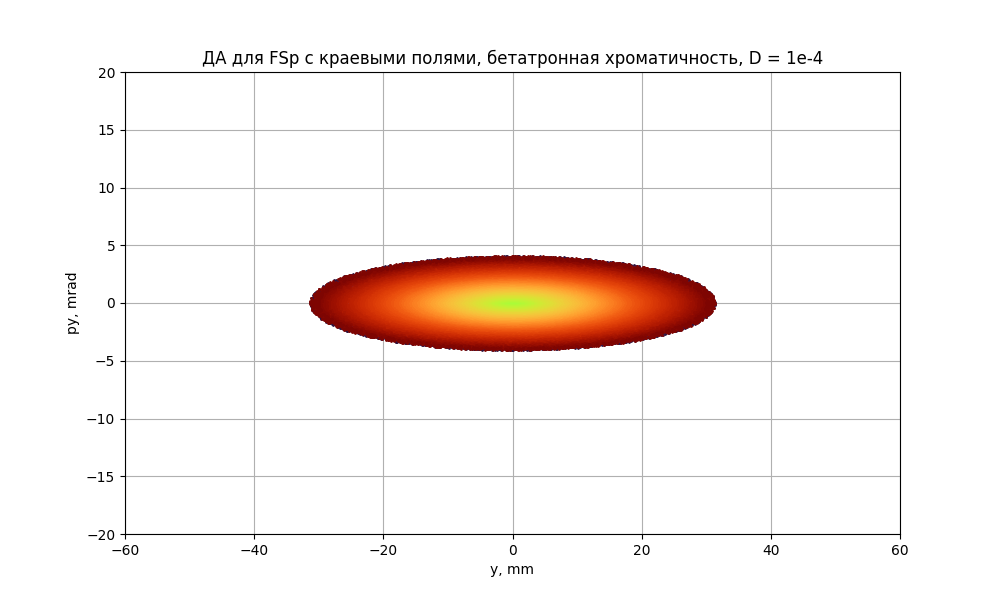

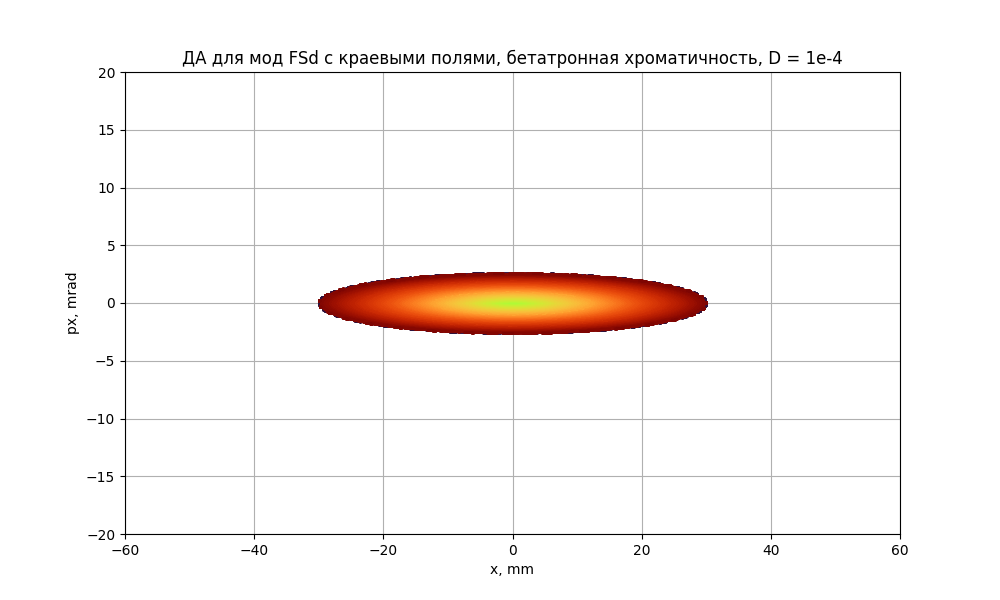

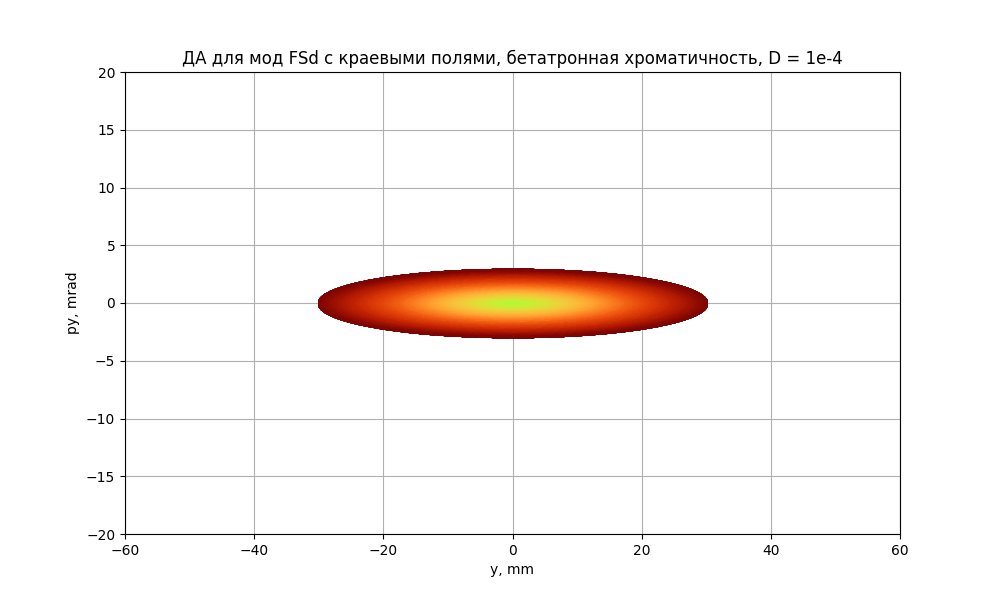

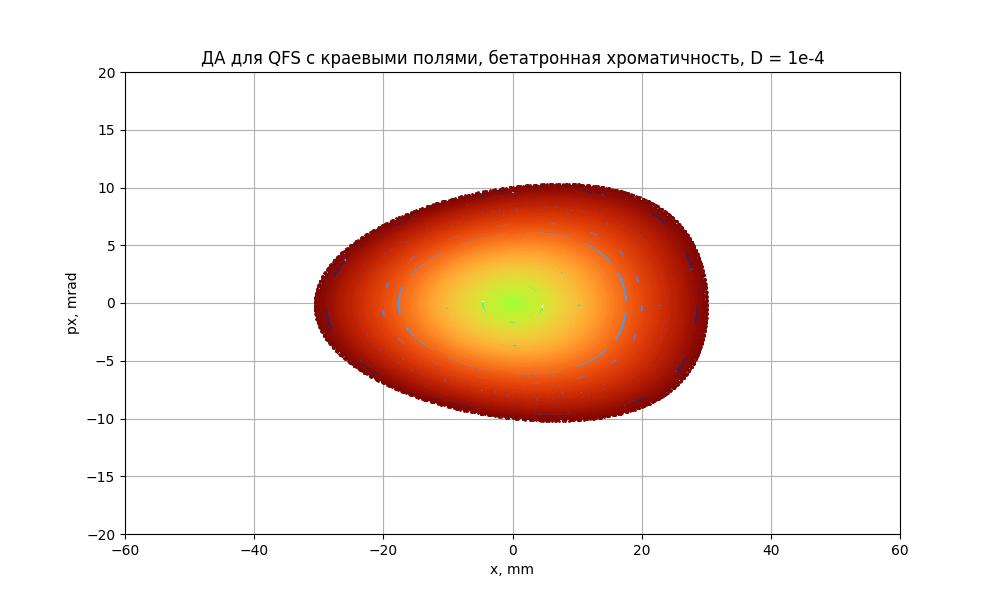

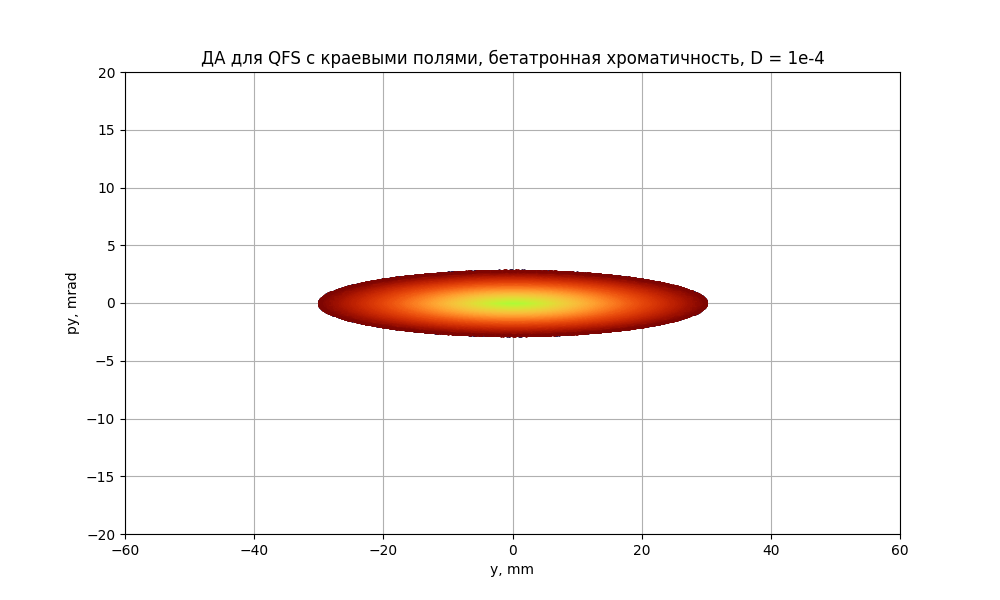

In [37]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mplcursors

selected_points = []

cursor = mplcursors.cursor(hover=False)

@cursor.connect("add")
def on_click(sel):
    i = sel.index
    selected_points.append(df.iloc[i])
    print(df.iloc[i])

rus = {
    "seq_FSp_fr3": "FSp",
    "seq_qfs_fr3": "QFS",
    "seq_dfs_pp1_fr3": "мод FSd",
    "seq_dfs_pp1_fr3": "мод FSd",
    "chrom_correction": "бетатронная хроматичность",
    "spin_coherence": "спиновая когерентность"
}
a = "seq_FSp"
b = "seq_qfs"
c = "seq_dfs_pp1"

for i in range(len(files)):
    if (files[i][3] != "natural_chrom") and (files[i][2] not in [a, b, c]):
        filename = f"{path}/{files[i][1]}.dat"
        names = ["iteration", "ray", "x", "a", "y", "b", "T", "D"]
        
        # Чтение и сортировка данных
        df = pd.read_csv(filename, comment="#", sep=r'\s+', names=names)
        df = df.sort_values(by=["iteration", "ray"])  # сначала по iteration, потом по ray
        
        colors = plt.cm.turbo(np.linspace(0, 1, tracking_vars[2] + 1))
       
        plt.figure(figsize=(10,6))
        for j in range(1, 4*(tracking_vars[2]) + 1, 4):
            rayxd = df[df['ray'] == j+2]
            plt.plot(
                rayxd['x']*1e3, rayxd['a']*1e3,
                color=colors[((j - 1)//4) % len(colors)],
                marker='o',
                linestyle='None',
                markersize=1,
            )
        plt.xlabel('x, mm')
        plt.xlim(-6e-2*1e3, 6e-2*1e3)
        plt.ylim(-0.02*1e3, 0.02*1e3)
        plt.ylabel('px, mrad')
        plt.title(f"ДА для {rus[files[i][2]]} с краевыми полями, {rus[files[i][3]]}, D = 1e-4")
        plt.grid(True)
        plt.show()
        
        plt.figure(figsize=(10,6))
        for j in range(1, 4*(tracking_vars[2]) + 1, 4):
            rayyd = df[(df['ray'] == j+3)]
            plt.plot(
                rayyd['y']*1e3, rayyd['b']*1e3,
                color=colors[((j - 1)//4) % len(colors)],
                marker='o',
                linestyle='None',
                markersize=1,
            )
        plt.xlabel('y, mm')
        plt.xlim(-6e-2*1e3, 6e-2*1e3)
        plt.ylim(-0.02*1e3, 0.02*1e3)
        plt.ylabel('py, mrad')
        plt.title(f"ДА для {rus[files[i][2]]} с краевыми полями, {rus[files[i][3]]}, D = 1e-4")
        plt.grid(True)
        plt.show()


In [34]:
import pandas as pd
import numpy as np

def table(ff):
    path = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/dynamic aperture/cosy"
    
    rus = {
        "seq_FSp": "FSp",
        "seq_qfs": "QFS",
        "seq_dfs_pp1": "FSd",
        "chrom_correction": "бетатронная_хроматичность",
        "spin_coherence": "спиновая_когерентность",
        "seq_FSp_fr3": "FSp",
        "seq_qfs_fr3": "QFS",
        "seq_dfs_pp1_fr3": "FSd"
    }
    
    fringe_items = {"seq_FSp_fr3", "seq_qfs_fr3", "seq_dfs_pp1_fr3"}

    ff_sorted = sorted(ff, key=lambda x: (x[2], x[3]))

    # пределы
    x_limit = 0.03
    px_limit = 0.015
    y_limit = 0.03
    py_limit = 0.015

    # окрестность осей
    eps = 5e-4

    output_file = f"{path}/table_template.dat"

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(f"#{'lattice':10} {'mode':25} {'fringe':25} {'plane':10} {'a':15} {'b':15} {'piab':15}\n")
        
        count = 0  # сколько реально записали
        
        for row in ff_sorted:
            # исключаем natural chrom
            if row[3].strip() == "natural_chrom":
                continue

            lattice = rus.get(row[2], row[2])
            mode = rus.get(row[3], row[3])
            fringe = "краевые_поля" if row[2] in fringe_items else "-"

            filename = f"{path}/{row[1]}.dat"
            names = ["iteration", "ray", "x", "a", "y", "b", "T", "D"]

            try:
                df = pd.read_csv(filename, comment="#", sep=r'\s+', names=names)
            except Exception as e:
                print(f"Ошибка чтения {filename}: {e}")
                continue

            # ========= X =========
            all_x = df[['x','a']].values

            stable_x = all_x[
                (np.abs(all_x[:,0]) <= x_limit) &
                (np.abs(all_x[:,1]) <= px_limit)
            ]

            if len(stable_x) == 0:
                print(f"Нет X точек: {row[1]}")
                continue

            near_px0 = stable_x[np.abs(stable_x[:,1]) < eps]
            near_x0  = stable_x[np.abs(stable_x[:,0]) < eps]

            a_x = np.max(np.abs(near_px0[:,0])) if len(near_px0) > 0 else np.max(np.abs(stable_x[:,0]))
            b_x = np.max(np.abs(near_x0[:,1])) if len(near_x0) > 0 else np.max(np.abs(stable_x[:,1]))

            area_x = np.pi * a_x * b_x * 1e6  # мм·мрад

            # ========= Y =========
            all_y = df[['y','b']].values

            stable_y = all_y[
                (np.abs(all_y[:,0]) <= y_limit) &
                (np.abs(all_y[:,1]) <= py_limit)
            ]

            if len(stable_y) == 0:
                print(f"Нет Y точек: {row[1]}")
                continue

            near_py0 = stable_y[np.abs(stable_y[:,1]) < eps]
            near_y0  = stable_y[np.abs(stable_y[:,0]) < eps]

            a_y = np.max(np.abs(near_py0[:,0])) if len(near_py0) > 0 else np.max(np.abs(stable_y[:,0]))
            b_y = np.max(np.abs(near_y0[:,1])) if len(near_y0) > 0 else np.max(np.abs(stable_y[:,1]))

            area_y = np.pi * a_y * b_y * 1e6  # мм·мрад

            # запись
            f.write(f"{lattice:10} {mode:25} {fringe:25} {'X':10} {a_x*1e3:15.6f} {b_x*1e3:15.6f} {area_x:15.6f}\n")
            f.write(f"{lattice:10} {mode:25} {fringe:25} {'Y':10} {a_y*1e3:15.6f} {b_y*1e3:15.6f} {area_y:15.6f}\n")

            count += 1

    print(f"Готово. Записано файлов: {count}")
    print(f"Файл: {output_file}")


# вызов
table(files)

Готово. Записано файлов: 12
Файл: C:/Users/palo4/Desktop/MEPHI/Master/HNP/dynamic aperture/cosy/table_template.dat
